In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
sample_dataset_url="https://drive.google.com/uc?export=download&id=1bHTIv_gZK_pcwiXoD7pS7k7ql-Tdu1mg" #URL to AMPd Dataset Electricity_CDE.csv (Granularity 1 min)
dataset=pd.read_csv(sample_dataset_url) 
dataset.head(5)

,unix_ts,V,I,f,DPF,APF,P,Pt,Q,Qt,S,St
0,1333263600,238.0,0.0,60.0,1.0,0.00,0,39791,0,5877,0,66147
1,1333263660,238.0,0.0,60.0,1.0,0.00,0,39791,0,5877,0,66148
2,1333263720,237.7,0.0,60.0,1.0,0.04,0,39791,0,5877,0,66148
3,1333263780,238.0,0.0,60.0,1.0,0.04,0,39791,0,5877,0,66148
4,1333263840,237.8,0.0,60.0,1.0,0.00,0,39791,0,5877,0,66148


In [56]:
Pt=dataset.loc[:,'Pt'].values # read actual recorded energy every minute (W.h)
Pt=Pt.reshape(-1,1)
P=dataset.loc[:,'P'].values # read actual recorded power every minute (W)
P=P.reshape(-1,1)

In [57]:
#Set target granularity period in seconds e.g. deltaT=3*60 means a granularity of 3 minutes will be used in the energy-advisor model
deltaT=3*60 # target granularity period in seconds (used to downsample Ampd dataset from 1 min (60 sec) to 3 min (180 sec))

In [58]:
# Actual recorded Power and Energy at target granularity
P=P[::int(deltaT/60)] #Actual recorded Power at target granularity in Watts
Pt=Pt[::int(deltaT/60)]/1000 #Actual recorded Energy at target granularity in KWh

In [59]:
# This cell is useful in case a dataset dos not have power readings and only has energy readings. In this case we need to estimate power from energy readings.
deltaPt=np.diff(Pt,1,0) # Calculate energy consumed in each granularity period (KWh)
deltaPt=np.vstack([0,deltaPt]) #add a zero at the start to match dimensions

# The estimated power consumed in Watts from the energy consumed in each granularity period with proper unit conversions since delataPt is in KWh and deltaT is in seconds
estP=deltaPt*1000*3600/deltaT

t=np.arange(0,len(deltaPt),1)
t=t.reshape(-1,1)



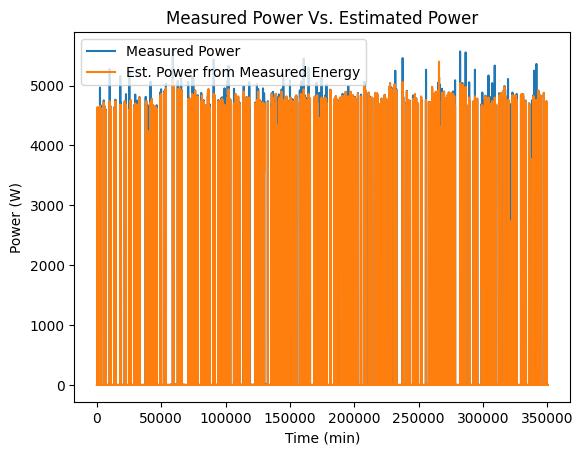

In [60]:
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(t,P,label='Measured Power')
ax.plot(t,estP,label='Est. Power from Measured Energy')
ax.set(title='Measured Power Vs. Estimated Power',ylabel='Power (W)',xlabel='Time (min)')
ax.legend(loc='best')
plt.show()

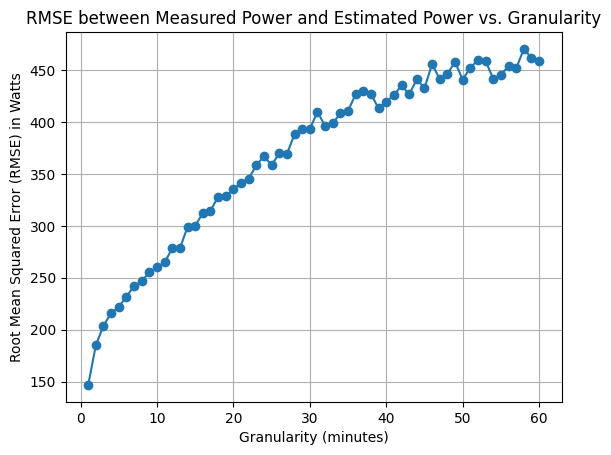

In [61]:
rmse_list = []

for deltaT in deltaT_range:
    P_down = dataset.loc[:, 'P'].values[::int(deltaT/60)].reshape(-1, 1)
    Pt_down = dataset.loc[:, 'Pt'].values[::int(deltaT/60)] / 1000
    Pt_down = Pt_down.reshape(-1, 1)
    deltaPt = np.diff(Pt_down, axis=0)
    deltaPt = np.vstack([0, deltaPt])
    estP = deltaPt * 1000 * 3600 / deltaT
    estP = estP.reshape(-1, 1)
    rmse = np.sqrt(np.mean((P_down - estP) ** 2))
    rmse_list.append(rmse)

plt.figure()
plt.plot(deltaT_range / 60, rmse_list, marker='o')
plt.xlabel('Granularity (minutes)')
plt.ylabel('Root Mean Squared Error (RMSE) in Watts')
plt.title('RMSE between Measured Power and Estimated Power vs. Granularity')
plt.grid(True)
plt.show()